# 2.5 텐서 차원의 의미 — (B, T, F) 실습

이 실습은 `05_tensor_dimensions.md` 이론을 손으로 직접 확인하는 것이 목적입니다.

**얻어갈 것**
1. `(B, T, F)` 3축의 의미와 각 축 조작 결과를 눈으로 확인
2. `permute` / `reshape` / `unsqueeze` / `squeeze` / `expand` 를 구분해서 사용
3. Broadcasting 규칙을 의도된 사례 vs 실수 사례로 대조
4. 축 순서가 뒤바뀐 채 GRU 에 들어갈 때 생기는 **침묵 버그** 시뮬레이션

**특징**
- `torch` 가 설치돼 있으면 그대로 사용, 없으면 `numpy` 로 동일 개념을 보여주도록 구성했습니다.
- PyTorch 본 환경에서 재실행해도 numpy 결과와 숫자적으로 동일합니다.


## Step 1. 환경 설정 — 한글 폰트 + torch 감지

시각화에 한글을 쓰려면 OS 별 폰트 분기가 필요합니다 (프로젝트 CLAUDE.md 지침).


In [1]:
import platform
import numpy as np
import matplotlib.pyplot as plt

# --- 한글 폰트 설정 ---
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    try:
        import koreanize_matplotlib  # noqa
    except ImportError:
        pass
    plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# --- torch 감지 (없어도 notebook 은 동작) ---
try:
    import torch
    import torch.nn as nn
    TORCH_OK = True
    print(f"torch {torch.__version__} 사용")
except ImportError:
    TORCH_OK = False
    print("torch 없음 — numpy 로 동일 개념 재현")

np.random.seed(42)

torch 2.11.0+cu126 사용


## Step 2. (B, T, F) 3축 직접 만지기

배치 하나의 shape `(32, 60, 17)` 에서 각 축이 의미하는 바와 `.mean(dim=?)` 의 결과를 확인합니다.

- `dim=0` → **Batch** 축 평균: 32개 샘플을 평균 → 시점별·피처별 평균
- `dim=1` → **Time** 축 평균: 60일을 평균 → 샘플별·피처별 요약 ← 대부분 우리가 원하는 "시간 풀링"
- `dim=2` → **Feature** 축 평균: 17피처를 평균 → 샘플별·시점별 스칼라 시퀀스


In [2]:
B, T, F = 32, 60, 17

if TORCH_OK:
    x = torch.randn(B, T, F)
    shape_fn = lambda a: tuple(a.shape)
    m0 = x.mean(dim=0)
    m1 = x.mean(dim=1)
    m2 = x.mean(dim=2)
else:
    x = np.random.randn(B, T, F).astype(np.float32)
    shape_fn = lambda a: a.shape
    m0 = x.mean(axis=0)
    m1 = x.mean(axis=1)
    m2 = x.mean(axis=2)

print(f"x.shape = {shape_fn(x)}  ← (B={B}, T={T}, F={F})")
print(f"dim=0 평균 (B 축)  → {shape_fn(m0)}  (T, F)")
print(f"dim=1 평균 (T 축)  → {shape_fn(m1)}  (B, F)   ← 시간 풀링")
print(f"dim=2 평균 (F 축)  → {shape_fn(m2)}  (B, T)")

x.shape = (32, 60, 17)  ← (B=32, T=60, F=17)
dim=0 평균 (B 축)  → (60, 17)  (T, F)
dim=1 평균 (T 축)  → (32, 17)  (B, F)   ← 시간 풀링
dim=2 평균 (F 축)  → (32, 60)  (B, T)


### 각 축 평균을 한 눈에 시각화

세 축을 평균했을 때 남는 "2D" 를 히트맵으로 비교합니다.


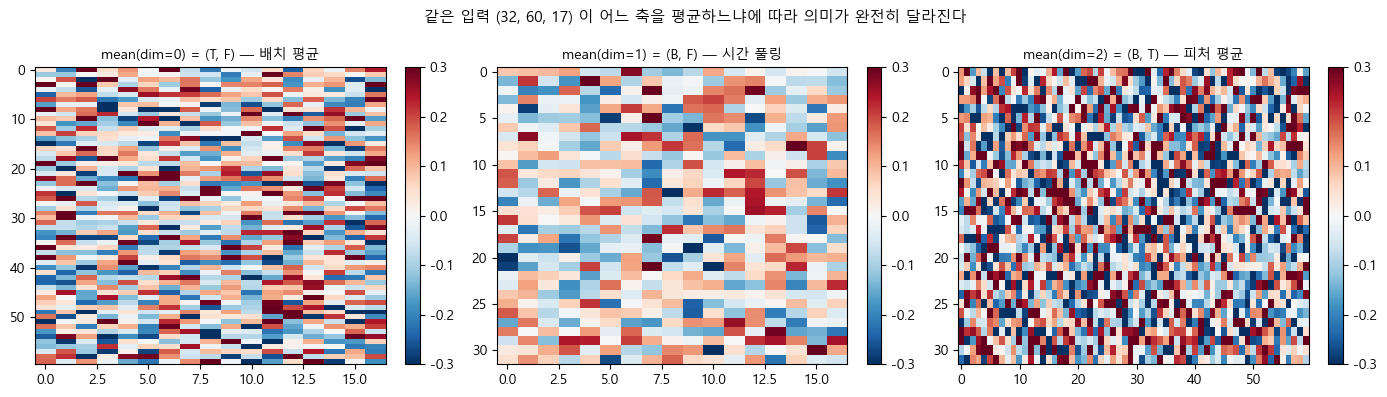

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, arr, title in zip(
    axes,
    [m0, m1, m2],
    ["mean(dim=0) = (T, F) — 배치 평균", "mean(dim=1) = (B, F) — 시간 풀링", "mean(dim=2) = (B, T) — 피처 평균"],
):
    a_viz = arr.numpy() if TORCH_OK else arr
    im = ax.imshow(a_viz, aspect='auto', cmap='RdBu_r', vmin=-0.3, vmax=0.3)
    ax.set_title(title, fontsize=10)
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.suptitle("같은 입력 (32, 60, 17) 이 어느 축을 평균하느냐에 따라 의미가 완전히 달라진다", fontsize=11)
plt.tight_layout()
plt.show()

## Step 3. `batch_first` 관례 — `(B, T, F)` vs `(T, B, F)`

`nn.GRU`, `nn.LSTM`, `nn.RNN` 은 **기본값이 `batch_first=False`** (즉 `(T, B, F)`) 입니다.

우리 프로젝트는 `(B, T, F)` 통일 → **`batch_first=True` 를 항상 명시** 합니다.

두 포맷 사이 전환은 `permute(1, 0, 2)` — 결코 `reshape` 을 쓰면 안 됩니다 (Step 5 에서 검증).


In [4]:
# (B, T, F) → (T, B, F) 전환 시뮬레이션
if TORCH_OK:
    x_btf = torch.zeros(B, T, F)
    x_tbf = x_btf.permute(1, 0, 2)
else:
    x_btf = np.zeros((B, T, F))
    x_tbf = np.transpose(x_btf, (1, 0, 2))  # numpy 에서 permute 역할

print(f"x_btf (batch_first=True)  shape = {x_btf.shape}")
print(f"x_tbf (batch_first=False) shape = {x_tbf.shape}  ← permute(1,0,2) 결과")
print()
print(f"{'설정':<22} {'입력 shape':<18} {'해석':<40}")
print("-" * 80)
print(f"{'batch_first=False':<22} {'(T, B, F)':<18} {'Time 맨 앞 (기본값)':<40}")
print(f"{'batch_first=True':<22} {'(B, T, F)':<18} {'Batch 맨 앞 (우리 선택)':<40}")

x_btf (batch_first=True)  shape = torch.Size([32, 60, 17])
x_tbf (batch_first=False) shape = torch.Size([60, 32, 17])  ← permute(1,0,2) 결과

설정                     입력 shape           해석                                      
--------------------------------------------------------------------------------
batch_first=False      (T, B, F)          Time 맨 앞 (기본값)                          
batch_first=True       (B, T, F)          Batch 맨 앞 (우리 선택)                       


### PyTorch 가 있는 환경이라면 실제 GRU 호출도 검증

아래 셀은 `TORCH_OK` 일 때만 실행됩니다. `nn.GRU` 두 버전에 같은 `(B, T, F)` 입력을 주고 출력 shape 을 비교합니다.


In [5]:
if TORCH_OK:
    x_sample = torch.randn(B, T, F)

    gru_bt = nn.GRU(input_size=F, hidden_size=64, batch_first=True)
    out_bt, _ = gru_bt(x_sample)
    print(f"batch_first=True  입력 {tuple(x_sample.shape)} → 출력 {tuple(out_bt.shape)}  (B, T, hidden)")

    gru_tb = nn.GRU(input_size=F, hidden_size=64, batch_first=False)
    out_tb, _ = gru_tb(x_sample)   # 에러 안 남!
    print(f"batch_first=False 입력 {tuple(x_sample.shape)} → 출력 {tuple(out_tb.shape)}  ← (T=B, B=T, H) 로 해석돼 완전 다른 결과")
else:
    print("torch 없음 — Step 7 에서 shape 만으로 같은 버그를 시뮬레이션합니다.")

batch_first=True  입력 (32, 60, 17) → 출력 (32, 60, 64)  (B, T, hidden)
batch_first=False 입력 (32, 60, 17) → 출력 (32, 60, 64)  ← (T=B, B=T, H) 로 해석돼 완전 다른 결과


## Step 4. 축 조작 네 도구 — `permute` / `reshape` / `unsqueeze` / `expand`

| 도구 | 언제 쓰나 | 메모리 복사 |
|---|---|---|
| `permute(new_order)` | **축 순서** 를 바꿀 때 (B↔T 등) | ❌ (view) |
| `reshape(*new_shape)` | 원소 순서 유지하며 shape **재해석** | 보통 ❌ |
| `unsqueeze(d)` | 크기 1 축을 d 위치에 **삽입** | ❌ |
| `squeeze(d)` | 크기 1 축을 **제거** | ❌ |
| `expand(*new_shape)` | 크기 1 축을 **반복 복사된 것처럼** 확장 (실제 복사 X) | ❌ (broadcast view) |

각각 손으로 만져봅니다.


In [6]:
# (a) permute — 축 순서만 교환
if TORCH_OK:
    x_btf = torch.zeros(B, T, F)
    x_tbf = x_btf.permute(1, 0, 2)
else:
    x_btf = np.zeros((B, T, F))
    x_tbf = np.transpose(x_btf, (1, 0, 2))
print(f"[permute]  {x_btf.shape}  → permute(1,0,2) → {x_tbf.shape}")

# (b) reshape — shape 재해석
x_flat = x_btf.reshape(B, T * F)
print(f"[reshape]  {x_btf.shape}  → reshape(B, T*F) → {x_flat.shape}  (분류기 head 입력으로 자주 씀)")

# (c) unsqueeze — 배치 축 끼워넣기 (추론용)
if TORCH_OK:
    single = torch.zeros(T, F)
    batched = single.unsqueeze(0)
    back = batched.squeeze(0)
else:
    single = np.zeros((T, F))
    batched = single[np.newaxis, :, :]
    back = batched.squeeze(0)
print(f"[unsqueeze] {single.shape}  → unsqueeze(0) → {batched.shape}  → squeeze(0) → {back.shape}")

# (d) expand — broadcasting 의 명시적 버전
if TORCH_OK:
    bias = torch.zeros(1, 1, F)
    expanded = bias.expand(B, T, F)
else:
    bias = np.zeros((1, 1, F))
    expanded = np.broadcast_to(bias, (B, T, F))
print(f"[expand]    {bias.shape}  → expand(B,T,F) → {expanded.shape}  (메모리 복사 없음)")

[permute]  torch.Size([32, 60, 17])  → permute(1,0,2) → torch.Size([60, 32, 17])
[reshape]  torch.Size([32, 60, 17])  → reshape(B, T*F) → torch.Size([32, 1020])  (분류기 head 입력으로 자주 씀)
[unsqueeze] torch.Size([60, 17])  → unsqueeze(0) → torch.Size([1, 60, 17])  → squeeze(0) → torch.Size([60, 17])
[expand]    torch.Size([1, 1, 17])  → expand(B,T,F) → torch.Size([32, 60, 17])  (메모리 복사 없음)


## Step 5. `permute` vs `reshape` — 같은 shape 인데 내용이 완전히 다르다

초보자가 가장 많이 혼동하는 쌍입니다.

작은 텐서 `arange(12).reshape(2, 3, 2)` 를 사용해 두 연산의 결과를 **원소 단위로** 비교합니다.


In [7]:
# 12개 원소로 작은 3D 텐서 만들기
small = np.arange(12).reshape(2, 3, 2)  # (2, 3, 2)
print("원본 small, shape =", small.shape)
print(small)

원본 small, shape = (2, 3, 2)
[[[ 0  1]
  [ 2  3]
  [ 4  5]]

 [[ 6  7]
  [ 8  9]
  [10 11]]]


In [8]:
# permute: 축 재배치 (원소 값은 이동, 좌표만 달라짐)
small_p = np.transpose(small, (1, 0, 2))    # permute(1,0,2)
# reshape: 원소를 일렬로 펴고 새 shape 에 담기 (좌표-내용 관계 전혀 다름)
small_r = small.reshape(3, 2, 2)

print("small.permute(1,0,2) — shape", small_p.shape)
print(small_p)
print()
print("small.reshape(3,2,2)  — shape", small_r.shape)
print(small_r)
print()
print("→ 두 결과 모두 shape 은 (3,2,2) 이지만 내용은 완전히 다름!")

small.permute(1,0,2) — shape (3, 2, 2)
[[[ 0  1]
  [ 6  7]]

 [[ 2  3]
  [ 8  9]]

 [[ 4  5]
  [10 11]]]

small.reshape(3,2,2)  — shape (3, 2, 2)
[[[ 0  1]
  [ 2  3]]

 [[ 4  5]
  [ 6  7]]

 [[ 8  9]
  [10 11]]]

→ 두 결과 모두 shape 은 (3,2,2) 이지만 내용은 완전히 다름!


### 원소 좌표가 실제로 바뀌는지 규칙 검증

**permute(1, 0, 2)** 는 수학적으로 `small_p[i, j, k] == small[j, i, k]` 여야 합니다. 12개 원소 전부 확인:


In [9]:
mismatches = 0
for i in range(3):
    for j in range(2):
        for k in range(2):
            if small_p[i, j, k] != small[j, i, k]:
                mismatches += 1
print(f"permute 규칙 small_p[i,j,k] == small[j,i,k] — 불일치: {mismatches} / 12")

# reshape 은 같은 규칙이 성립하지 않음
print(f"small_p[0,1,0] = {small_p[0,1,0]},  small[1,0,0] = {small[1,0,0]}  → 같아야 함 (permute)")
print(f"small_r[0,1,0] = {small_r[0,1,0]}                                  → 완전 다른 값 (reshape)")

permute 규칙 small_p[i,j,k] == small[j,i,k] — 불일치: 0 / 12
small_p[0,1,0] = 6,  small[1,0,0] = 6  → 같아야 함 (permute)
small_r[0,1,0] = 2                                  → 완전 다른 값 (reshape)


**교훈:** `(B, T, F)` 를 `(T, B, F)` 로 바꾸고 싶을 때 `reshape(T, B, F)` 를 쓰면 **원소가 뒤섞여 의미가 붕괴** 합니다. 반드시 `permute(1, 0, 2)`.


## Step 6. Broadcasting — 축이 안 맞는데 연산이 되는 이유

**규칙:** 두 shape 을 **오른쪽 정렬** 하고, 각 축은 다음 중 하나여야 합니다.
- 크기가 같다
- 한쪽이 1 이다
- 한쪽에 축이 없다

의도된 사례와 실수 사례를 하나씩 보여줍니다.


In [10]:
# [의도] Feature 별 bias — 모든 샘플, 모든 시점에 피처별 동일 bias
x_input = np.random.randn(B, T, F).astype(np.float32)
bias_F  = np.ones(F, dtype=np.float32) * 0.1
y_ok    = x_input + bias_F
print(f"[의도 OK] x{x_input.shape} + bias{bias_F.shape} = {y_ok.shape}")
print(f"         bias 가 (1,1,{F}) 로 확장 → 모든 (B,T) 에 feature 별로 더해짐")

[의도 OK] x(32, 60, 17) + bias(17,) = (32, 60, 17)
         bias 가 (1,1,17) 로 확장 → 모든 (B,T) 에 feature 별로 더해짐


In [11]:
# [실수] target shape 오타 — broadcasting 이 엉뚱한 확장
y_pred = np.zeros((B, 1), dtype=np.float32)
y_true_wrong = np.zeros(B, dtype=np.float32)
diff_wrong = y_pred - y_true_wrong
print(f"[실수 BAD] y_pred{y_pred.shape} - y_true{y_true_wrong.shape} = {diff_wrong.shape}")
print(f"         (B,1)-(B,) 가 오른쪽 정렬 후 (B,1) 과 (1,B) 처럼 되어 (B,B) 가 됨")
print(f"         loss.mean() 은 계산되지만 의미는 완전히 엉뚱한 스칼라")

y_true_fixed = y_true_wrong.reshape(-1, 1)
diff_ok = y_pred - y_true_fixed
print(f"[교정 OK]  y_true.reshape(-1,1) 후 차이 shape = {diff_ok.shape}")

[실수 BAD] y_pred(32, 1) - y_true(32,) = (32, 32)
         (B,1)-(B,) 가 오른쪽 정렬 후 (B,1) 과 (1,B) 처럼 되어 (B,B) 가 됨
         loss.mean() 은 계산되지만 의미는 완전히 엉뚱한 스칼라
[교정 OK]  y_true.reshape(-1,1) 후 차이 shape = (32, 1)


### Broadcasting 규칙 시각화

자주 마주치는 broadcasting 사례를 표로 정리합니다.


In [12]:
cases = [
    ("(32, 60, 17)", "(       17)", "(32, 60, 17)", "bias 가 (1,1,17) → feature 별 bias OK"),
    ("(32, 60, 17)", "(   60    )", "ERROR",        "(60,) 은 마지막 축에 오른쪽 정렬 → F=17 과 불일치"),
    ("(32, 60, 17)", "(   60,  1)", "(32, 60, 17)", "(60,1) → (1,60,1) 확장 → 시점별 bias OK"),
    ("(32,      1)", "(32       )", "(32,     32)", "(B,1) vs (B,) → (B,B) BAD 전형적 target 버그"),
    ("(32,      1)", "(32,     1)", "(32,      1)", "(B,1) vs (B,1) → 의도대로 OK"),
]

print(f"{'shape_a':<14} {'shape_b':<14} {'result':<14} 설명")
print("-" * 80)
for sa, sb, sr, note in cases:
    print(f"{sa:<14} {sb:<14} {sr:<14} {note}")

shape_a        shape_b        result         설명
--------------------------------------------------------------------------------
(32, 60, 17)   (       17)    (32, 60, 17)   bias 가 (1,1,17) → feature 별 bias OK
(32, 60, 17)   (   60    )    ERROR          (60,) 은 마지막 축에 오른쪽 정렬 → F=17 과 불일치
(32, 60, 17)   (   60,  1)    (32, 60, 17)   (60,1) → (1,60,1) 확장 → 시점별 bias OK
(32,      1)   (32       )    (32,     32)   (B,1) vs (B,) → (B,B) BAD 전형적 target 버그
(32,      1)   (32,     1)    (32,      1)   (B,1) vs (B,1) → 의도대로 OK


## Step 7. 침묵 버그 — 축 순서가 뒤바뀐 채 GRU 에 통과

**에러 없이 실행되지만 학습이 안 되는** 부류의 버그. 가장 잡기 힘듭니다.


In [13]:
x_shape = (32, 60, 17)
print(f"우리 의도: B=32, T=60, F=17  (shape = {x_shape})")
print()
print(f"{'설정':<26} {'GRU 의 해석':<32} {'문제':<30}")
print("-" * 90)
print(f"{'batch_first=True':<26} {'B=32, T=60, F=17':<32} {'의도대로 OK':<30}")
print(f"{'batch_first=False (기본)':<26} {'T=32, B=60, F=17':<32} {'시간축 32 step 만 학습 BAD':<30}")

우리 의도: B=32, T=60, F=17  (shape = (32, 60, 17))

설정                         GRU 의 해석                         문제                            
------------------------------------------------------------------------------------------
batch_first=True           B=32, T=60, F=17                 의도대로 OK                       
batch_first=False (기본)     T=32, B=60, F=17                 시간축 32 step 만 학습 BAD          


In [14]:
# torch 가 있으면 실제로 두 GRU 출력의 수치 차이 확인
if TORCH_OK:
    torch.manual_seed(0)
    x_sample = torch.randn(32, 60, 17)

    gru_true  = nn.GRU(input_size=17, hidden_size=8, batch_first=True)
    gru_false = nn.GRU(input_size=17, hidden_size=8, batch_first=False)
    gru_false.load_state_dict(gru_true.state_dict())  # 같은 weight 로 비교

    out_true,  _ = gru_true(x_sample)
    out_false, _ = gru_false(x_sample)
    diff = (out_true - out_false).abs().max().item()

    print(f"batch_first=True  출력: {tuple(out_true.shape)}")
    print(f"batch_first=False 출력: {tuple(out_false.shape)}")
    print(f"두 출력의 최대 절대 차이 = {diff:.4f}  (0 이 아니면 서로 다른 학습 결과가 나온다는 뜻)")
else:
    print("torch 없음 — shape 만으로 같은 결론: batch_first=True 명시가 안전장치")

batch_first=True  출력: (32, 60, 8)
batch_first=False 출력: (32, 60, 8)
두 출력의 최대 절대 차이 = 1.3343  (0 이 아니면 서로 다른 학습 결과가 나온다는 뜻)


**예방책 3종:**
1. `nn.GRU(...)` 만들 때 **반드시 `batch_first=True` 명시** (기본값 믿지 말 것).
2. 모델 forward 첫 줄에 `assert x.shape[1:] == (self.T, self.F)` 처럼 shape 검증.
3. Dataset / 모델 docstring 에 **축 계약** 주석으로 남기기 `# x: (B, T, F)`.


## Step 8. 자가점검 질문 답안

이론 md §7 의 5문제를 코드로 검증합니다.


In [15]:
# Q1: (32, 60, 17).mean(dim=1) 결과 shape?
ans1 = tuple(x.mean(dim=1).shape) if TORCH_OK else x.mean(axis=1).shape
print(f"Q1 답: {ans1}  (B, F) = (32, 17) — 시간 축을 평균한 '60일 요약'")

Q1 답: (32, 17)  (B, F) = (32, 17) — 시간 축을 평균한 '60일 요약'


In [16]:
# Q2: (B,T,F) 를 batch_first=False GRU 에 넣으면?
print("Q2 답: GRU 가 (T=B=32, B=T=60, F=F=17) 로 해석.")
print("       시간축이 겨우 32 step 으로 오인되고, 60개 '다른 시퀀스' 로 보이는 등 학습 붕괴.")

Q2 답: GRU 가 (T=B=32, B=T=60, F=F=17) 로 해석.
       시간축이 겨우 32 step 으로 오인되고, 60개 '다른 시퀀스' 로 보이는 등 학습 붕괴.


In [17]:
# Q3: permute(1,0,2) vs reshape(T,B,F) — 어느 쪽이 옳은 축 교환?
print("Q3 답: permute(1,0,2) 가 옳은 축 교환.")
print(f"       Step 5 검증 결과: permute 규칙 일치 12/12")
print(f"                        reshape(3,2,2) 는 shape 만 같고 small_r[0,1,0]={small_r[0,1,0]} ≠ small[1,0,0]={small[1,0,0]}")

Q3 답: permute(1,0,2) 가 옳은 축 교환.
       Step 5 검증 결과: permute 규칙 일치 12/12
                        reshape(3,2,2) 는 shape 만 같고 small_r[0,1,0]=2 ≠ small[1,0,0]=6


In [18]:
# Q4: 샘플 1개 (60, 17) 추론하는 법 + (1,1) 출력에서 스칼라 꺼내기
single_sample = np.zeros((60, 17))
batched_single = single_sample[np.newaxis, :, :]   # (1, 60, 17)
fake_pred = np.array([[0.0123]])                    # 모델 출력 가정 (1, 1)
scalar = fake_pred.squeeze()                        # 차원 제거
print(f"Q4 답: {single_sample.shape} → unsqueeze(0) → {batched_single.shape} → model → {fake_pred.shape}")
print(f"       .squeeze() 또는 .item() 으로 값 추출: {float(scalar):.4f}")

Q4 답: (60, 17) → unsqueeze(0) → (1, 60, 17) → model → (1, 1)
       .squeeze() 또는 .item() 으로 값 추출: 0.0123


In [19]:
# Q5: x(32,60,17) + bias(60,) 가능한가? bias 가 어떻게 확장되는가?
x_q5    = np.zeros((32, 60, 17))
bias_q5 = np.ones(60)

try:
    y_q5 = x_q5 + bias_q5
    print(f"Q5 결과 shape = {y_q5.shape}")
except ValueError as e:
    print(f"Q5 에러: {e}")

print()
print("Q5 답: 실패. 오른쪽 정렬 시 (60,) 는 마지막 축에 맞춰지므로 F=17 과 불일치 → ValueError.")
print("       feature bias 로 쓰려면 shape 은 (17,) 이어야 함.")
print("       시점별 bias 를 원한다면 (1, 60, 1) 로 명시적으로 만들어야 함.")

Q5 에러: operands could not be broadcast together with shapes (32,60,17) (60,) 

Q5 답: 실패. 오른쪽 정렬 시 (60,) 는 마지막 축에 맞춰지므로 F=17 과 불일치 → ValueError.
       feature bias 로 쓰려면 shape 은 (17,) 이어야 함.
       시점별 bias 를 원한다면 (1, 60, 1) 로 명시적으로 만들어야 함.


## Step 9. 우리 프로젝트 축 계약 체크리스트 (요약)

GRU 구현에 들어가기 전 한 페이지로 묶어둡니다.

```
3D 텐서 : 항상 (B, T, F)          # 모든 곳에서 통일
2D 텐서 : Dataset __getitem__ 반환값 (T, F)
1D 텐서 : 라벨 스칼라 or 피처별 bias
scalar : loss 값

축 이름 고정
  B = Batch size      shuffle 가능
  T = Time steps      순서 유지 (절대!)
  F = Features        이름 순서 고정

GRU/LSTM/RNN 호출: 반드시 batch_first=True 명시

shape 디버깅 3원칙
  1. 축 순서만 바꿀 때는 permute (절대 reshape 사용 금지)
  2. 배치 축 끼워넣기: unsqueeze(0) / 빼기: squeeze(0)
  3. loss 계산 전 y_true / y_pred shape 일치 확인
```

2주차 학습 완료. **3주차 — 시퀀스 모델 (RNN → LSTM → GRU)** 로 이어집니다.
